In [1]:
import os
os.chdir("../") # resets notebook directory to repository root folder (DO ONLY ONCE!)
import polars as pl
import pandas as pd
import pyarrow.parquet as pypq
import textwrap
from pathlib import Path
import time

from tqdm.auto import tqdm
tqdm.pandas()

In [2]:
import sys
# Add utils directory in the list of directories to look for packages to import
sys.path.insert(0, os.path.join(os.getcwd(),'utils'))
from read_parquet import *

Using PyArrow strings!


In [3]:
works_by_topic_parquet_folder = "data/works_by_topic_parquet/"
works2sdg_by_topic_parquet_folder = "data/works2sdg_by_topic_parquet/"
os.makedirs(works2sdg_by_topic_parquet_folder, exist_ok=True)

In [4]:
topics = [topic[:-8] for topic in os.listdir(works_by_topic_parquet_folder)]

In [5]:
len(topics)

4516

In [6]:
def get_sdg_scores(x):
    if not x or pd.isna(x):
        return []  # empty if missing
    parts = [i.split('_') for i in x.split(';')]
    return parts   # e.g. [['SDG1','0.9'], ['SDG2','0.8']]

def generate_sdg_score_df(parquet_file_path):
    # Read only needed columns
    works_df = read_parquet(parquet_file_path, columns=["id", "date", "sdg"], quiet=True)

    # Parse sdg into list of [sdg, score]
    works_df['sdg_list'] = works_df['sdg'].apply(get_sdg_scores)

    # Drop rows where list is empty
    works_df = works_df[works_df['sdg_list'].map(len) > 0]

    # Expand sdg_list into multiple rows
    works_df = works_df.explode('sdg_list')
    works_df = works_df.reset_index().rename(columns={'index': 'works_by_topic_index'})

    # Split sdg_list into two columns: sdg, score
    works_df[['sdg', 'score']] = pd.DataFrame(works_df['sdg_list'].tolist(), index=works_df.index)

    # Drop helper column
    works_df = works_df.drop(columns=['sdg_list'])

    # Convert score to float
    works_df['score'] = works_df['score'].astype(float)

    return works_df

def create_sdg_score_df(origin_works_parquet_file_path, destination_topic_parquet_file_path, compression='brotli', do_peek = True, do_print = True):
    works_df = generate_sdg_score_df(origin_works_parquet_file_path)
    works_df.to_parquet(destination_topic_parquet_file_path, compression=compression)
    if do_print:
        print(f"Successfully generated {destination_topic_parquet_file_path} using {origin_works_parquet_file_path}.")
    if do_peek:
        if do_print:
            print("Here's a peek.")
        peek_parquet(destination_topic_parquet_file_path)

In [7]:
for topic in tqdm(topics):
    origin_works_parquet_file_path = works_by_topic_parquet_folder+topic+".parquet"
    destination_topic_parquet_file_path = works2sdg_by_topic_parquet_folder+topic+".parquet"
    create_sdg_score_df(origin_works_parquet_file_path, destination_topic_parquet_file_path, do_peek = False, do_print = False)

  0%|          | 0/4516 [00:00<?, ?it/s]

In [8]:
peek_parquet(destination_topic_parquet_file_path)

Name: 'T10091'
Path: 'data/works2sdg_by_topic_parquet/T10091.parquet'
Files: 1
Rows: 111,561
Schema:
    works_by_topic_index: int64
    id: large_string
    date: large_string
    sdg: large_string
    score: double
    -- schema metadata --
    pandas: '{"index_columns": [{"kind": "range", "name": null, "start": 0, "' + 827
5 random rows:


,works_by_topic_index,id,date,sdg,score
0,1,W6963238420,2028-01-01,3,0.629328
1,3,W6925566458,2028-01-01,2,0.581009
2,5,W7125586755,2026-03-08,3,0.663369
3,6,W7125584245,2026-03-08,3,0.663369
4,7,W7126399418,2026-02-01,3,0.682872


  0%|          | 0/4516 [00:00<?, ?it/s]

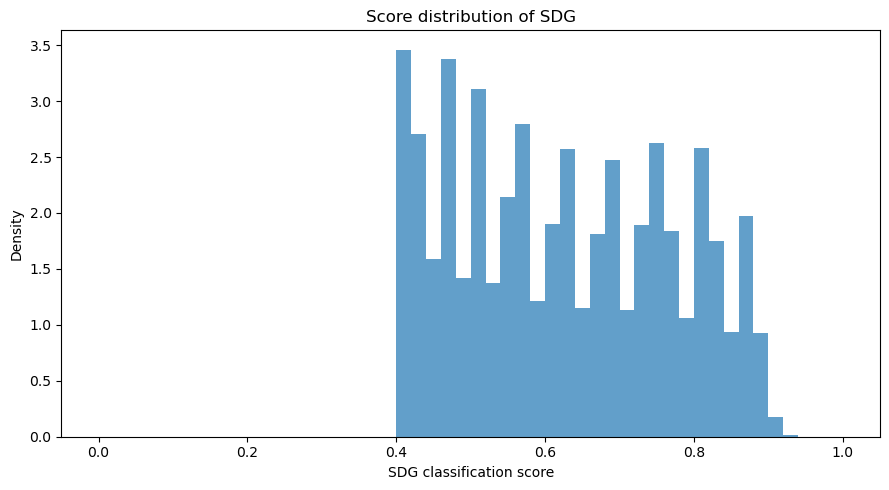

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# assuming you already have: topics, works2topic_by_topic_parquet_folder
all_dfs = []

for topic in tqdm(topics):
    p = f"{works2sdg_by_topic_parquet_folder}{topic}.parquet"
    df = pd.read_parquet(p, columns=["sdg","score"])
    df = df.copy()
    all_dfs.append(df)

# merge everything
df_all = pd.concat(all_dfs, ignore_index=True)

# columns to plot
score_cols = ["score"]

bins = np.linspace(0, 1, 51)

plt.figure(figsize=(9, 5))

for i, c in enumerate(score_cols):
    scores = df_all[c].astype(float).clip(0, 1)
    plt.hist(
        scores,
        bins=bins,
        density=True,
        alpha=0.7,
        label=c
    )

# labels
plt.xlabel("SDG classification score")
plt.ylabel("Density")
plt.title("Score distribution of SDG")
# plt.legend()

plt.tight_layout()
os.makedirs("figures", exist_ok = True)
plt.savefig("figures/all_sdg_scores_hist.png", dpi=300)
plt.savefig("figures/all_sdg_scores_hist.pdf")
plt.show()

In [10]:
for c in score_cols:
    scores = df_all[c].astype(float).clip(0, 1)
    total  = len(scores)
    print(f"total rows = {total:,}")
    print(f"average = {scores.mean()}")
    print(f"std = {scores.std()}")

total rows = 146,673,011
average = 0.6258445707320676
std = 0.14543908912957407
